# Theme 12: 앙상블 학습 및 머신러닝 프로세스 마무리 (2026-04-30)

오늘의 학습 목표:
1. 앙상블 학습(Ensemble Learning)의 개념과 종류(Voting, Bagging, Boosting)를 이해합니다.
2. Random Forest 모델을 구축하고 하이퍼파라미터를 튜닝합니다.
3. 특성 중요도(Feature Importance)를 시각화하여 모델의 판단 근거를 분석합니다.
4. Scikit-Learn Pipeline을 활용하여 전처리와 모델링 과정을 통합합니다.

## 1. 환경 설정 및 데이터 로드

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier, VotingRegressor, StackingClassifier, StackingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, r2_score, mean_absolute_error, precision_recall_curve, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from imblearn.ensemble import BalancedRandomForestClassifier

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'NanumGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

In [2]:
adm = pd.read_csv('content/admission_simple.csv')

target = 'ADMIT'

X = adm.drop(target, axis=1)
y = adm[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

def matrix_c(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'name={model.__class__.__name__}')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    c = cross_val_score( model, X_train, y_train, cv=10, scoring="accuracy")
    print(f"평균 : {c.mean():0.4f}")
    print(f"표준편차 : {c.std():0.5f}")
    print('='*70)
model_knn = KNeighborsClassifier()
model_dt = DecisionTreeClassifier()
model_lg = LogisticRegression()
model_svc = SVC()
model_rf = RandomForestClassifier()
model_xgb = XGBClassifier()
model_lgbm = LGBMClassifier(max_depth=5, num_leaves=30, learning_rate=0.1, verbose = -1)

matrix_c(model_knn, X_train_s, y_train, X_test_s, y_test)
matrix_c(model_dt, X_train_s, y_train, X_test_s, y_test)
matrix_c(model_lg, X_train, y_train, X_test, y_test)
matrix_c(model_svc, X_train, y_train, X_test, y_test)
matrix_c(model_xgb, X_train, y_train, X_test, y_test)
matrix_c(model_lgbm, X_train, y_train, X_test, y_test)

name=KNeighborsClassifier
[[79  5]
 [15 51]]
              precision    recall  f1-score   support

           0       0.84      0.94      0.89        84
           1       0.91      0.77      0.84        66

    accuracy                           0.87       150
   macro avg       0.88      0.86      0.86       150
weighted avg       0.87      0.87      0.86       150

평균 : 0.8543
표준편차 : 0.06318
name=DecisionTreeClassifier
[[75  9]
 [13 53]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        84
           1       0.85      0.80      0.83        66

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150

평균 : 0.8000
표준편차 : 0.06761
name=LogisticRegression
[[76  8]
 [15 51]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        84
           1       0.86      0.77      0.82     

In [3]:
boston = pd.read_csv('content/boston.csv')

target = 'medv'

X = boston.drop(target, axis=1)
y = boston[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

def matrix_r(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'name={model.__class__.__name__}')
    print(f'{mean_absolute_error(y_test, y_pred):4f}')
    print(f'{r2_score(y_test, y_pred):4f}')
    print('='*70)

model_lr = LinearRegression()
model_knn = KNeighborsRegressor()
model_dt = DecisionTreeRegressor()
model_rf = RandomForestRegressor()
model_lgbm = LGBMRegressor(
    min_child_samples=5,
    max_depth=15,
    min_split_gain=0,
    colsample_bytree=1.0,
    verbose=-1)

matrix_r(model_lr, X_train, y_train, X_test, y_test)
matrix_r(model_knn, X_train_s, y_train, X_test_s, y_test)
matrix_r(model_dt, X_train_s, y_train, X_test_s, y_test)
matrix_r(model_rf, X_train, y_train, X_test, y_test)
matrix_r(model_lgbm, X_train, y_train, X_test, y_test)

estimators = [('lr', make_pipeline(scaler, model_lr)),
              ('dt', model_dt),
              ('knn', make_pipeline(scaler, model_knn)),
              ('rdf', model_rf)]

model_vt = VotingRegressor(estimators=estimators)

matrix_r(model_vt, X_train, y_train, X_test, y_test)

name=LinearRegression
3.439838
0.772168
name=KNeighborsRegressor
3.287895
0.753884
name=DecisionTreeRegressor
2.913158
0.781155
name=RandomForestRegressor
2.296901
0.898575
name=LGBMRegressor
2.347964
0.888789
name=VotingRegressor
2.517796
0.857927


In [4]:
dia = pd.read_csv('content/diabetes.csv')

target = 'Outcome'

X = dia.drop(target, axis=1)
y = dia[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

model_knn = KNeighborsClassifier()
model_dt = DecisionTreeClassifier()
model_lg = LogisticRegression()
model_lgbm = LGBMClassifier()


matrix_c(model_knn, X_train_s, y_train, X_test_s, y_test)
matrix_c(model_dt, X_train_s, y_train, X_test_s, y_test)
matrix_c(model_lg, X_train, y_train, X_test, y_test)
matrix_c(model_lgbm, X_train, y_train, X_test, y_test)

estimators = [('lr', make_pipeline(scaler, model_lg)),
              ('dt', model_dt),
              ('knn', make_pipeline(scaler, model_knn)),
              ('lgbm', model_lgbm)]

model = StackingClassifier(estimators=estimators, final_estimator=model_lg)

matrix_c(model, X_train, y_train, X_test, y_test)


name=KNeighborsClassifier
[[129  17]
 [ 35  50]]
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       146
           1       0.75      0.59      0.66        85

    accuracy                           0.77       231
   macro avg       0.77      0.74      0.75       231
weighted avg       0.77      0.77      0.77       231

평균 : 0.6890
표준편차 : 0.04847
name=DecisionTreeClassifier
[[119  27]
 [ 41  44]]
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       146
           1       0.62      0.52      0.56        85

    accuracy                           0.71       231
   macro avg       0.68      0.67      0.67       231
weighted avg       0.70      0.71      0.70       231

평균 : 0.7057
표준편차 : 0.05452
name=LogisticRegression
[[132  14]
 [ 36  49]]
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       146
           1       0.78      0.58   

In [5]:
mobile = pd.read_csv('content/mobile_cust_churn.csv')

target = 'CHURN'

mobile.drop(['id'], axis=1, inplace=True)

# 2. 새로운 변수 생성 (초과 사용 비중)
mobile['OVERAGE_RATIO'] = mobile['OVERAGE'] / (mobile['OVERAGE'] + mobile['LEFTOVER'] + 1)
# 3. 새로운 변수 생성 (자산 대비 소득 비중)
mobile['HOUSE_INCOME_RATIO'] = mobile['HOUSE'] / (mobile['INCOME'] + 1)
# 4. 범주화 (초과 사용 여부)
mobile['ANY_OVERAGE'] = (mobile['OVERAGE'] > 0).astype(int)

# 1. 모든 가변수화 데이터의 상관계수를 구합니다.
corr_matrix = pd.get_dummies(mobile, drop_first=True).corr()
# 2. 타겟(CHURN_STAY 또는 LEAVE)과 다른 변수 간의 상관계수 절댓값을 구합니다.
# (drop_first=True를 쓰면 CHURN_STAY 하나만 남습니다.)
target_corr = corr_matrix['CHURN_STAY'].abs()
# 3. 절댓값이 0.05 이상인 컬럼명만 리스트로 뽑습니다.
# (자기 자신인 'CHURN_STAY'는 제외합니다.)
selected_features = target_corr[target_corr >= 0.05].index.drop('CHURN_STAY')
# 4. 결과 확인
print(f"선택된 변수 ({len(selected_features)}개): \n{selected_features.tolist()}")
# 5. 최종 X 데이터 구성
origin_X = X = pd.get_dummies(mobile.drop(target, axis=1), drop_first=True)
X = pd.get_dummies(mobile, drop_first=True)[selected_features]
y = mobile[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=1)
X_train, X_test, y_train_e, y_test_e = train_test_split(X,LabelEncoder().fit_transform(y), train_size=0.7, random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

model_rf = RandomForestClassifier(max_depth=10, min_samples_split=2, n_estimators=30, n_jobs=-1)
model_lgbm = LGBMClassifier(max_depth=5, num_leaves=31, learning_rate=0.1, n_estimators=100, verbose = -1)

voting_model = VotingClassifier(
    estimators=[('rf', model_rf), ('lgbm', model_lgbm)],
    voting='soft'
)
matrix_c(voting_model, X_train, y_train, X_test, y_test)

선택된 변수 (9개): 
['INCOME', 'OVERAGE', 'LEFTOVER', 'HOUSE', 'HANDSET_PRICE', 'OVER_15MINS_CALLS_PER_MONTH', 'OVERAGE_RATIO', 'HOUSE_INCOME_RATIO', 'ANY_OVERAGE']
name=VotingClassifier
[[2207  728]
 [1073 1992]]
              precision    recall  f1-score   support

       LEAVE       0.67      0.75      0.71      2935
        STAY       0.73      0.65      0.69      3065

    accuracy                           0.70      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.70      0.70      0.70      6000

평균 : 0.6985
표준편차 : 0.01179


선택된 변수 (9개): 
['Age', 'DistanceFromHome', 'JobSatisfaction', 'MonthlyIncome', 'TotalWorkingYears', 'Burnout', 'MaritalStatus_Married', 'MaritalStatus_Single', 'OverTime_Yes']
[[219  81]
 [ 16  43]]
              precision    recall  f1-score   support

           0       0.93      0.73      0.82       300
           1       0.35      0.73      0.47        59

    accuracy                           0.73       359
   macro avg       0.64      0.73      0.64       359
weighted avg       0.84      0.73      0.76       359



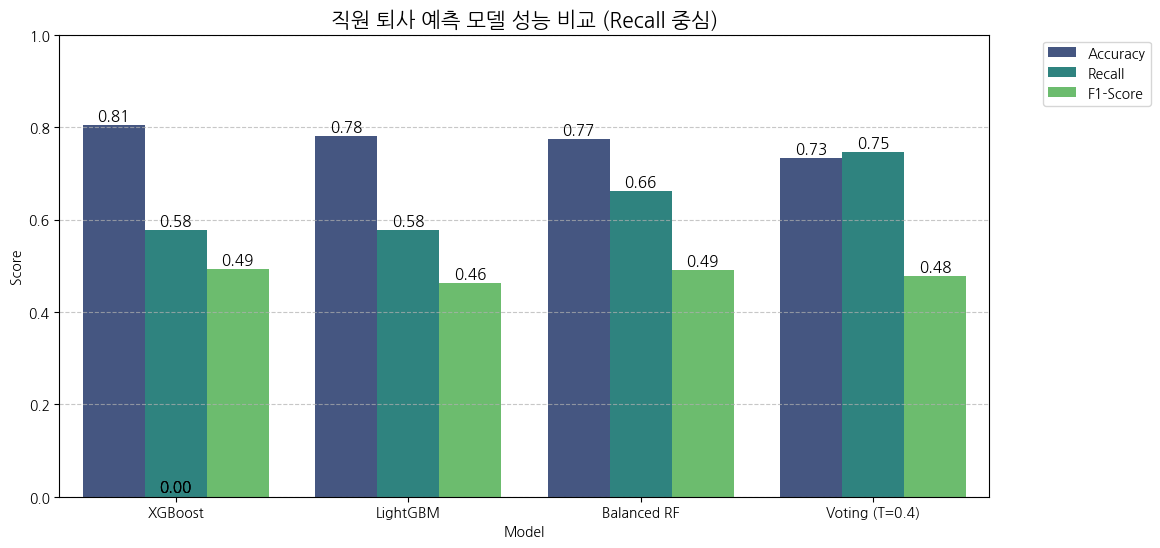

In [ ]:
attr = pd.read_csv('content/attrition.csv')

target = 'Attrition'

attr['Burnout'] = attr['DistanceFromHome'] * (attr['OverTime'] == 'Yes').astype(int)

corr_matrix = pd.get_dummies(attr, drop_first=True).corr()
target_corr = corr_matrix[target].abs()
selected_features = target_corr[target_corr >= 0.05].index.drop(target)
print(f"선택된 변수 ({len(selected_features)}개): \n{selected_features.tolist()}")

X = pd.get_dummies(attr, drop_first=True)[selected_features]
y = attr[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

model_xgb = XGBClassifier(colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 100, scale_pos_weight= 5, subsample= 0.8)
model_lgbm = LGBMClassifier(max_depth=5, num_leaves=100, learning_rate=0.05, verbose = -1, is_unbalance=True)
model_brf = BalancedRandomForestClassifier(
    max_depth= 5, max_features= 'sqrt', min_samples_leaf= 2, n_estimators= 200, sampling_strategy= 0.8
)
model_voting = VotingClassifier(
    estimators=[
        ('xgb', model_xgb), 
        ('lgbm', model_lgbm), 
        ('brf', model_brf)
    ],
    voting='soft',
    weights=[1,1,2]
)


# 1. 비교할 모델 리스트
models = [model_xgb, model_lgbm, model_brf, model_voting]
model_names = ['XGBoost', 'LightGBM', 'Balanced RF', 'Voting (T=0.4)']
# 2. 성능 지표 수집
results = []
for i, model in enumerate(models):
    # Voting 모델만 우리가 정한 임계값 0.4 적용
    model.fit(X_train, y_train)
    if i == 3:
        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = (y_probs >= 0.4).astype(int)
    else:
        y_pred = model.predict(X_test)
        
    results.append({
        'Model': model_names[i],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
df_res = pd.DataFrame(results)
# 3. 시각화 (Recall과 F1-Score 위주)
df_melt = df_res.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melt, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('직원 퇴사 예측 모델 성능 비교 (Recall 중심)', fontsize=15)
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# 수치 표시
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                       textcoords='offset points')
plt.show()

In [ ]:
airline = pd.read_csv('content/airline_satisfaction_small.csv')

airline['arrival_delay_in_minutes'] = airline['arrival_delay_in_minutes'].fillna(airline['departure_delay_in_minutes'])

airline.drop(['id', 'age'], axis=1, inplace=True)

target = 'satisfaction'

X = pd.get_dummies(airline.drop(target,axis=1), drop_first=True)
y = airline[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

model_dt = DecisionTreeClassifier()
model_rf = RandomForestClassifier()
model_xgb = XGBClassifier()
model_lgbm = LGBMClassifier(max_depth=5, num_leaves=30, learning_rate=0.1, verbose = -1)

matrix_c(model_dt, X_train_s, y_train, X_test_s, y_test)
matrix_c(model_rf, X_train, y_train, X_test, y_test)
matrix_c(model_xgb, X_train, y_train, X_test, y_test)
matrix_c(model_lgbm, X_train, y_train, X_test, y_test)

name=DecisionTreeClassifier
[[387  35]
 [ 40 313]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       422
           1       0.90      0.89      0.89       353

    accuracy                           0.90       775
   macro avg       0.90      0.90      0.90       775
weighted avg       0.90      0.90      0.90       775

평균 : 0.9003
표준편차 : 0.03006
name=RandomForestClassifier
[[407  15]
 [ 33 320]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       422
           1       0.96      0.91      0.93       353

    accuracy                           0.94       775
   macro avg       0.94      0.94      0.94       775
weighted avg       0.94      0.94      0.94       775

평균 : 0.9291
표준편차 : 0.02022
name=XGBClassifier
[[407  15]
 [ 30 323]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       422
           1       0.96      0.92      

In [103]:
airline_final = airline[airline['flight_distance'] <= 4000.0]

def categorize_distance(dist):
    if dist < 1000: 
        return 'Short-haul'
    elif dist < 2500: 
        return 'Medium-haul'
    else: 
        return 'Long-haul'
airline_final['distance_type'] = airline_final['flight_distance'].apply(categorize_distance)
airline_final['class_dist_combined'] = airline_final['class'] + "_" + airline_final['distance_type']

class_map = {'Eco': 1, 'Eco Plus': 2, 'Business': 3}
airline_final['class_score'] = airline_final['class'].map(class_map)

# 값이 음수면 비행 중 시간을 단축했다는 뜻 (만족도 상승 요인)
airline_final['Delay_Diff'] = airline_final['arrival_delay_in_minutes'] - airline_final['departure_delay_in_minutes']

# 아예 지연 여부를 0과 1로 쪼개기
airline_final['Is_Delayed'] = (airline_final['arrival_delay_in_minutes'] > 0).astype(int)

service_cols = ['inflight_wifi_service', 'ease_of_online_booking', 'online_boarding', 'departure/arrival_time_convenient', 'seat_comfort', 'inflight_entertainment', 'cleanliness', 'food_and_drink', 'leg_room_service', 'on-board_service', 'baggage_handling', 'checkin_service', 'inflight_service', 'gate_location']

# 점수의 들쭉날쭉한 정도(표준편차)
airline_final['Service_Consistency'] = airline_final[service_cols].std(axis=1)

# 0점(서비스 미이용) 개수 카운트
airline_final['Zero_Score_Count'] = (airline_final[service_cols] == 0).sum(axis=1)

X = pd.get_dummies(airline_final.drop(target,axis=1), drop_first=True)
y = airline_final[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

model_dt = DecisionTreeClassifier()
model_rf = RandomForestClassifier()
model_xgb = XGBClassifier()
model_lgbm = LGBMClassifier(max_depth=5, num_leaves=30, learning_rate=0.1, verbose = -1)

matrix_c(model_dt, X_train_s, y_train, X_test_s, y_test)
matrix_c(model_rf, X_train, y_train, X_test, y_test)
matrix_c(model_xgb, X_train, y_train, X_test, y_test)
matrix_c(model_lgbm, X_train, y_train, X_test, y_test)

name=DecisionTreeClassifier
[[398  34]
 [ 35 307]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       432
           1       0.90      0.90      0.90       342

    accuracy                           0.91       774
   macro avg       0.91      0.91      0.91       774
weighted avg       0.91      0.91      0.91       774

평균 : 0.9008
표준편차 : 0.01474
name=RandomForestClassifier
[[411  21]
 [ 39 303]]
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       432
           1       0.94      0.89      0.91       342

    accuracy                           0.92       774
   macro avg       0.92      0.92      0.92       774
weighted avg       0.92      0.92      0.92       774

평균 : 0.9268
표준편차 : 0.02119
name=XGBClassifier
[[408  24]
 [ 30 312]]
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       432
           1       0.93      0.91      

In [109]:
import optuna

# Optuna 진행 과정에서 나오는 불필요한 로그(정보) 숨기기
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. 최적화할 목표 함수(Objective Function) 정의
def objective(trial):
    # 탐색할 하이퍼파라미터 공간 정의 (LightGBM 핵심 파라미터들)
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        # log=True를 주면 0.01 쪽에 더 촘촘하게 탐색합니다.
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbose': -1
    }
    
    # 튜닝할 모델 객체 생성
    model = LGBMClassifier(**params)
    
    # 교차 검증(CV)으로 성능 평가 (CV=5)
    # n_jobs=-1로 설정하여 병렬 처리로 속도 향상
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    
    # 5번의 CV 결과의 평균을 반환 (이 값을 최대화하는 것이 Optuna의 목표)
    return score.mean()

# 2. Optuna Study 생성 및 실행
print("Optuna 하이퍼파라미터 튜닝 시작 (50회 반복)...")
# 우리가 원하는 건 정확도(accuracy)가 '가장 높은(maximize)' 모델을 찾는 것
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))

# 최적화 실행 (n_trials=50으로 50번 시도)
study.optimize(objective, n_trials=10)

# 3. 결과 출력
print(f"최고 CV 정확도: {study.best_value:.4f}")
print("최적의 파라미터:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# 4. 찾은 최적 파라미터로 최종 모델 평가하기
best_lgbm_optuna = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
print("\n[최적화된 LightGBM 모델의 최종 테스트 성능]")
matrix_c(best_lgbm_optuna, X_train, y_train, X_test, y_test)

Optuna 하이퍼파라미터 튜닝 시작 (50회 반복)...


최고 CV 정확도: 0.9374
최적의 파라미터:
  n_estimators: 337
  learning_rate: 0.011492999300221412
  max_depth: 9
  num_leaves: 42
  min_child_samples: 7
  subsample: 0.9795542149013333
  colsample_bytree: 0.9862528132298237

[최적화된 LightGBM 모델의 최종 테스트 성능]
name=LGBMClassifier
[[415  17]
 [ 37 305]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       432
           1       0.95      0.89      0.92       342

    accuracy                           0.93       774
   macro avg       0.93      0.93      0.93       774
weighted avg       0.93      0.93      0.93       774

평균 : 0.9346
표준편차 : 0.01760
